# Module 6.5: Practice Notebook — Exploratory Data Analysis (EDA)
# Dataset: Loan Approval Dataset

---

## 🎯 এই Dataset দিয়ে কী Achieve করতে চাই?

এটি একটি **Loan Approval** dataset। একটি bank বিভিন্ন আবেদনকারীর তথ্য দেখে সিদ্ধান্ত নেয় — তাকে loan দেওয়া হবে কিনা।

`loan_approved` column বলছে সেই আবেদনকারী loan পেয়েছে কিনা (`True` = পেয়েছে, `False` = পায়নি)।

**মূল প্রশ্ন:** একজন ব্যক্তির income, credit score, loan amount, employment duration ইত্যাদি দেখে কি predict করা যাবে সে loan পাবে কিনা?

---

## ✅ এই EDA থেকে কী Achieve করব?

| লক্ষ্য | কারণ |
|---|---|
| Dataset-এর গঠন বোঝা | কোন columns আছে, কী ধরনের data |
| Missing values খোঁজা | Data clean কিনা যাচাই করা |
| কোন features loan approval-এর সাথে সবচেয়ে related | সেগুলো ML model-এ সবচেয়ে বেশি কাজে আসবে |
| Outlier detect করা | Unusual income বা loan amount আছে কিনা |
| Class imbalance দেখা | Approved vs Rejected ratio কত |

---

## 🧠 তুমি যা শিখেছ, সেই আলোকে চিন্তার উপায়

| আগে যা শিখেছ | এখানে কীভাবে লাগবে |
|---|---|
| **Feature Types** | Numeric: income, credit_score, loan_amount, years_employed, points। Categorical: city (1882 unique!) |
| **Missing Values** | এই dataset-এ কোনো missing value নেই — clean dataset |
| **Feature Scaling** | Income ($30K–$150K) vs Credit Score (300–850) — range আলাদা, scale করতে হবে |
| **Encoding** | `city` column-এ 1882 unique city — One-Hot Encoding কঠিন হবে, Target Encoding বা drop করা যেতে পারে |
| **Outlier Detection** | IQR দিয়ে income ও loan_amount-এ outlier দেখব |
| **Correlation** | `points` ও `credit_score` — এই দুটো loan approval-এর সাথে সবচেয়ে বেশি correlated |

---

## 🗺️ EDA-এর Structure (Practice Template অনুযায়ী)

```
Section 1  → Dataset Selection and Brief Description
Section 2  → Upload Dataset and Load into Pandas
Section 3  → Basic Dataset Information (Shape, Info, Describe)
Section 4  → Identify Target Column and Feature Types
Section 5  → Missing Values and Basic Quality Checks
Section 6  → Distributions: Histograms and Boxplots
Section 7  → Target Distribution and Class Imbalance
Section 8  → Categorical Feature Exploration
Section 9  → Numeric Features vs Target (Boxplots)
Section 10 → Pairplot and Correlation Analysis
Section 11 → Categorical Features vs Target (Crosstab + Stacked Bar)
Section 12 → Final Summary and EDA Insights
```

---
## Section 1 — Dataset Selection and Brief Description

### Student Notes and Observations

**Selected Dataset:** Loan Approval Dataset  
**Kaggle URL:** https://www.kaggle.com/datasets/anishdevedward/loan-approval-dataset

**Brief Description:**  
এই dataset-এ বিভিন্ন bank loan আবেদনকারীর তথ্য আছে — তাদের income, credit score, loan amount, কত বছর চাকরি করেছে, এবং একটি internal scoring point। এই তথ্যের উপর ভিত্তি করে bank সিদ্ধান্ত নিয়েছে loan দেবে কিনা।

**Target Column:** `loan_approved` — Boolean (True = Loan Approved, False = Loan Rejected)

**Dataset Size:** 2000 rows × 8 columns  
**Missing Values:** কোনো missing value নেই — এটি একটি clean, synthetic dataset।

**⚠️ বিশেষ লক্ষ্যনীয়:** `points` column-এ একটি আকর্ষণীয় pattern আছে — 60 বা তার বেশি points হলে সবসময় loan approved, 55 বা তার কম হলে সবসময় rejected। এটি EDA-তে বিস্তারিত দেখব।

---
## Section 2 — Upload the Dataset and Load into Pandas

In [2]:
# Now we import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Here we've set a clean, consistent style for all charts
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f9f9f9'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.size']        = 11

print("Libraries loaded!")

# ─────────────────────────────────────────────────────────────
# Now we load the dataset
# This works in TWO ways:
#   • Google Colab  → uploads a file using the file picker
#   • Local / IDE   → reads directly from your local folder
# ─────────────────────────────────────────────────────────────

try:
    # ---------- Google Colab path ----------
    import google.colab
    from google.colab import files
    print("Running on Google Colab — please upload your CSV file.")
    uploaded = files.upload()          # a file picker will appear
    CSV_FILE = list(uploaded.keys())[0]
    print(f"Uploaded file: {CSV_FILE}")

except ImportError:
    # ---------- Local / IDE path ----------
    # Here we look for the CSV in the same folder as this notebook
    CSV_FILE = 'Loan Approval Dataset.csv'
    if not os.path.exists(CSV_FILE):
        raise FileNotFoundError(
            f"Could not find '{CSV_FILE}'. "
            "Please place it in the same folder as this notebook."
        )
    print(f"Running locally — loading '{CSV_FILE}' from current folder.")

# Here we've loaded the CSV into a pandas DataFrame
df = pd.read_csv(CSV_FILE)

print(f"\nDataset loaded! Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
df.head()

Libraries loaded!
Running locally — loading 'Loan Approval Dataset.csv' from current folder.

Dataset loaded! Shape: 2000 rows × 8 columns



,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


### Student Notes and Observations

উপরের code দুটি ভিন্ন environment-এ কাজ করে:
- **Google Colab-এ:** `files.upload()` দিয়ে একটি file picker খুলবে — সেখান থেকে `loan_approval.csv` select করো
- **Local IDE-তে (VS Code / PyCharm / Jupyter):** notebook-এর পাশের folder-এ `loan_approval.csv` রাখলেই automatically load হবে

`df.head()` দিয়ে প্রথম ৫টি row দেখা হচ্ছে।

**প্রথম দেখায় যা লক্ষ্য করার:**
- `name` ও `city` column আছে — এগুলো সরাসরি ML-এ ব্যবহার করা যাবে না
- `loan_approved` column boolean (True/False) — ML model-এর জন্য পরে 1/0 করতে হবে
- `points` column-এ শুধু নির্দিষ্ট কিছু মান আছে (10, 15, 20 ... 100) — এটি discrete

---
## Section 3 — Basic Dataset Information (Shape, Info, Describe)

In [3]:
# Now we print the shape of the dataset
print("=" * 55)
print(f"  Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("=" * 55)

# Here we've shown detailed column info — dtype, non-null count, missing
print()
print(f"{'Column':<18} {'Dtype':<12} {'Non-Null':<10} {'Missing':<10} {'Missing %'}")
print("-" * 60)
for col in df.columns:
    non_null   = df[col].notnull().sum()
    null_count = df[col].isnull().sum()
    null_pct   = null_count / len(df) * 100
    flag       = " ⚠️" if null_count > 0 else ""
    print(f"  {col:<16} {str(df[col].dtype):<12} {non_null:<10} {null_count:<10} {null_pct:.1f}%{flag}")

  Dataset Shape: 2000 rows × 8 columns

Column             Dtype        Non-Null   Missing    Missing %
------------------------------------------------------------
  name             object       2000       0          0.0%
  city             object       2000       0          0.0%
  income           int64        2000       0          0.0%
  credit_score     int64        2000       0          0.0%
  loan_amount      int64        2000       0          0.0%
  years_employed   int64        2000       0          0.0%
  points           float64      2000       0          0.0%
  loan_approved    bool         2000       0          0.0%


উপরের table-এ প্রতিটি column-এর data type এবং missing value count দেখা হয়েছে।

**Dtype মানে:**
- `int64` → পূর্ণ সংখ্যা (income, credit_score, loan_amount, years_employed)
- `float64` → দশমিক সংখ্যা (points)
- `str` / `object` → text (name, city)
- `bool` → True/False (loan_approved)

এই dataset-এ **কোনো missing value নেই** — এটি একটি clean, synthetic dataset।

In [4]:
# Now we look at descriptive statistics for all numeric columns
# .T means transpose — rows become columns, easier to read
print("Descriptive Statistics (Transposed):")
print()

# Here we've shown count, mean, std, min, quartiles and max
df.describe().T.round(2)

Descriptive Statistics (Transposed):



,count,mean,std,min,25%,50%,75%,max
income,2000.0,90585.98,34487.87,30053.0,61296.25,90387.5,120099.75,149964.0
credit_score,2000.0,573.95,160.56,300.0,433.00,576.0,715.00,850.0
loan_amount,2000.0,25308.50,14207.32,1022.0,12748.75,25661.5,37380.50,49999.0
years_employed,2000.0,20.44,11.78,0.0,10.00,21.0,31.00,40.0
points,2000.0,56.68,18.64,10.0,45.00,55.0,70.00,100.0


`.describe().T` প্রতিটি numeric column-এর statistical summary দেয় (Transposed মানে উল্টো করা — column গুলো এখন row-এ)।

**প্রতিটি row কী বলছে:**
- **count** → কতটি non-null value আছে
- **mean** → গড় মান
- **std** → Standard Deviation — মান কতটা ছড়িয়ে আছে
- **min / max** → সর্বনিম্ন ও সর্বোচ্চ মান
- **25% / 50% / 75%** → Q1, Median, Q3

**গুরুত্বপূর্ণ পর্যবেক্ষণ:**
- `income`: $30K থেকে $150K — wide range, scaling দরকার
- `credit_score`: 300 থেকে 850 — standard credit score range
- `points`: 10 থেকে 100, শুধু 5-এর গুণিতক — discrete feature
- `loan_amount`: $1K থেকে $50K — outlier দেখতে হবে

---
## Section 4 — Identify Target Column and Feature Types

In [5]:
# Now we identify the target column and separate features by type
TARGET = 'loan_approved'

# Here we've listed numeric, categorical, and ignored columns separately
numeric_features = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']

# city has 1882 unique values — too many for simple encoding, we keep it for exploration
categorical_features = ['city']

# name is a unique identifier — not useful for ML
ignore_cols = ['name']

# Here we've printed a clean summary
print("=" * 55)
print(f"  TARGET column   : {TARGET}")
print(f"  Numeric features: {numeric_features}")
print(f"  Categorical     : {categorical_features}")
print(f"  Ignored (no ML) : {ignore_cols}")
print("=" * 55)
print()
print(f"Unique cities: {df['city'].nunique()}")
print(f"Points unique values: {sorted(df['points'].unique().tolist())}")

  TARGET column   : loan_approved
  Numeric features: ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']
  Categorical     : ['city']
  Ignored (no ML) : ['name']

Unique cities: 1882
Points unique values: [10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0, 85.0, 90.0, 95.0, 100.0]


### Student Notes and Observations

**Target column:** `loan_approved` (Boolean → পরে 0/1 করতে হবে)

**Feature-গুলোকে ভাগ করা হয়েছে:**

| Column | Type | ML-এ ব্যবহার | কারণ |
|---|---|---|---|
| `income` | Numeric | ✅ হ্যাঁ | পরিষ্কার সংখ্যা |
| `credit_score` | Numeric | ✅ হ্যাঁ | পরিষ্কার সংখ্যা |
| `loan_amount` | Numeric | ✅ হ্যাঁ | পরিষ্কার সংখ্যা |
| `years_employed` | Numeric | ✅ হ্যাঁ | পরিষ্কার সংখ্যা |
| `points` | Numeric (Discrete) | ✅ হ্যাঁ | তবে এটি প্রায় target-ই বলে দেয়! |
| `city` | Categorical | ⚠️ কঠিন | 1882 unique value — Target Encoding বা drop |
| `name` | Text ID | ❌ না | সবার নাম unique — কোনো pattern নেই |

**⚠️ বিশেষ সতর্কতা:** `points` column-এ এমন pattern আছে যে এটি একাই loan approval নির্ধারণ করে দেয়। Real-world ML-এ এরকম column থাকলে সেটি **data leakage** হতে পারে — মানে এই column হয়তো approval-এর পরে তৈরি হয়েছে, আগে নয়।

---
## Section 5 — Missing Values and Basic Quality Checks

In [6]:
# Now we check for missing values
print("Missing Value Check:")
print("-" * 40)
missing = df.isna().sum()

# Here we've printed missing count and percentage for each column
for col in df.columns:
    count = missing[col]
    pct   = count / len(df) * 100
    status = "✅ No missing" if count == 0 else f"⚠️  {count} missing ({pct:.1f}%)"
    print(f"  {col:<18} {status}")

print()
print(f"Total missing values: {missing.sum()}")

Missing Value Check:
----------------------------------------
  name               ✅ No missing
  city               ✅ No missing
  income             ✅ No missing
  credit_score       ✅ No missing
  loan_amount        ✅ No missing
  years_employed     ✅ No missing
  points             ✅ No missing
  loan_approved      ✅ No missing

Total missing values: 0


**Observation:** এই dataset-এ কোনো missing value নেই। এটি একটি synthetic (কৃত্রিমভাবে তৈরি) dataset, তাই এত clean।  
Real-world dataset-এ সাধারণত missing value থাকে — সেক্ষেত্রে median বা mode দিয়ে fill করতে হয়।

In [7]:
# Now we check min, max, mean, median for each numeric feature
print("Numeric Feature — Basic Stats:")
print("-" * 70)
print(f"{'Feature':<20} {'Min':>10} {'Max':>10} {'Mean':>12} {'Median':>12}")
print("-" * 70)

# Here we've aggregated min, max, mean, median for every numeric column
for col in numeric_features:
    stats = df[col].agg(['min', 'max', 'mean', 'median'])
    print(f"  {col:<18} {stats['min']:>10.1f} {stats['max']:>10.1f} "
          f"{stats['mean']:>12.1f} {stats['median']:>12.1f}")

Numeric Feature — Basic Stats:
----------------------------------------------------------------------
Feature                     Min        Max         Mean       Median
----------------------------------------------------------------------
  income                30053.0   149964.0      90586.0      90387.5
  credit_score            300.0      850.0        573.9        576.0
  loan_amount            1022.0    49999.0      25308.5      25661.5
  years_employed            0.0       40.0         20.4         21.0
  points                   10.0      100.0         56.7         55.0


`.agg(['min','max','mean','median'])` দিয়ে প্রতিটি numeric column-এর মূল statistics একসাথে দেখা হয়েছে।

**লক্ষ্য করো:**
- `income`: Min $30K, Max $150K — range বড়, scaling লাগবে
- `credit_score`: 300–850 — standard FICO range, সঠিক মনে হচ্ছে
- `loan_amount`: $1K–$50K — বৈধ range
- `years_employed`: 0–40 — 0 মানে সদ্য নিয়োগ হয়েছে
- `points`: 10–100, Mean ≈ 57 — এটি একটি internal scoring

In [8]:
# Now we check unique values for categorical columns
print("Categorical Column — Unique Values:")
print("-" * 50)

# Here we've printed unique value counts and a few sample values
for col in categorical_features:
    unique_vals = df[col].unique()
    print(f"  {col}: {len(unique_vals)} unique values")
    print(f"  Sample: {list(unique_vals[:5])}")
    print()

# Also check the target column distribution
print("Target Column — loan_approved:")
print(df['loan_approved'].value_counts())

# Here we've also checked points breakdown because it's a key feature
print()
print("Points column — all unique values:")
print(sorted(df['points'].unique().tolist()))

Categorical Column — Unique Values:
--------------------------------------------------
  city: 1882 unique values
  Sample: ['East Jill', 'New Jamesside', 'Lake Roberto', 'West Melanieview', 'Mariastad']

Target Column — loan_approved:
loan_approved
False    1121
True      879
Name: count, dtype: int64

Points column — all unique values:
[10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0, 85.0, 90.0, 95.0, 100.0]


**Categorical column observation:**
- `city` column-এ **1882 unique city name** আছে — এত বেশি unique value-র column সরাসরি One-Hot Encoding করা যাবে না (1882টি নতুন column তৈরি হয়ে যাবে!)
  - Option 1: Drop করে দাও
  - Option 2: **Target Encoding** — প্রতিটি city-এর approval rate দিয়ে replace করো

**`points` column observation:**
- শুধু 19টি unique মান আছে: 10, 15, 20, 25 ... 100
- এটি একটি **discrete, ordinal** feature — বড় মান মানে ভালো

---
## Section 6 — Distributions: Histograms and Boxplots for Numeric Features

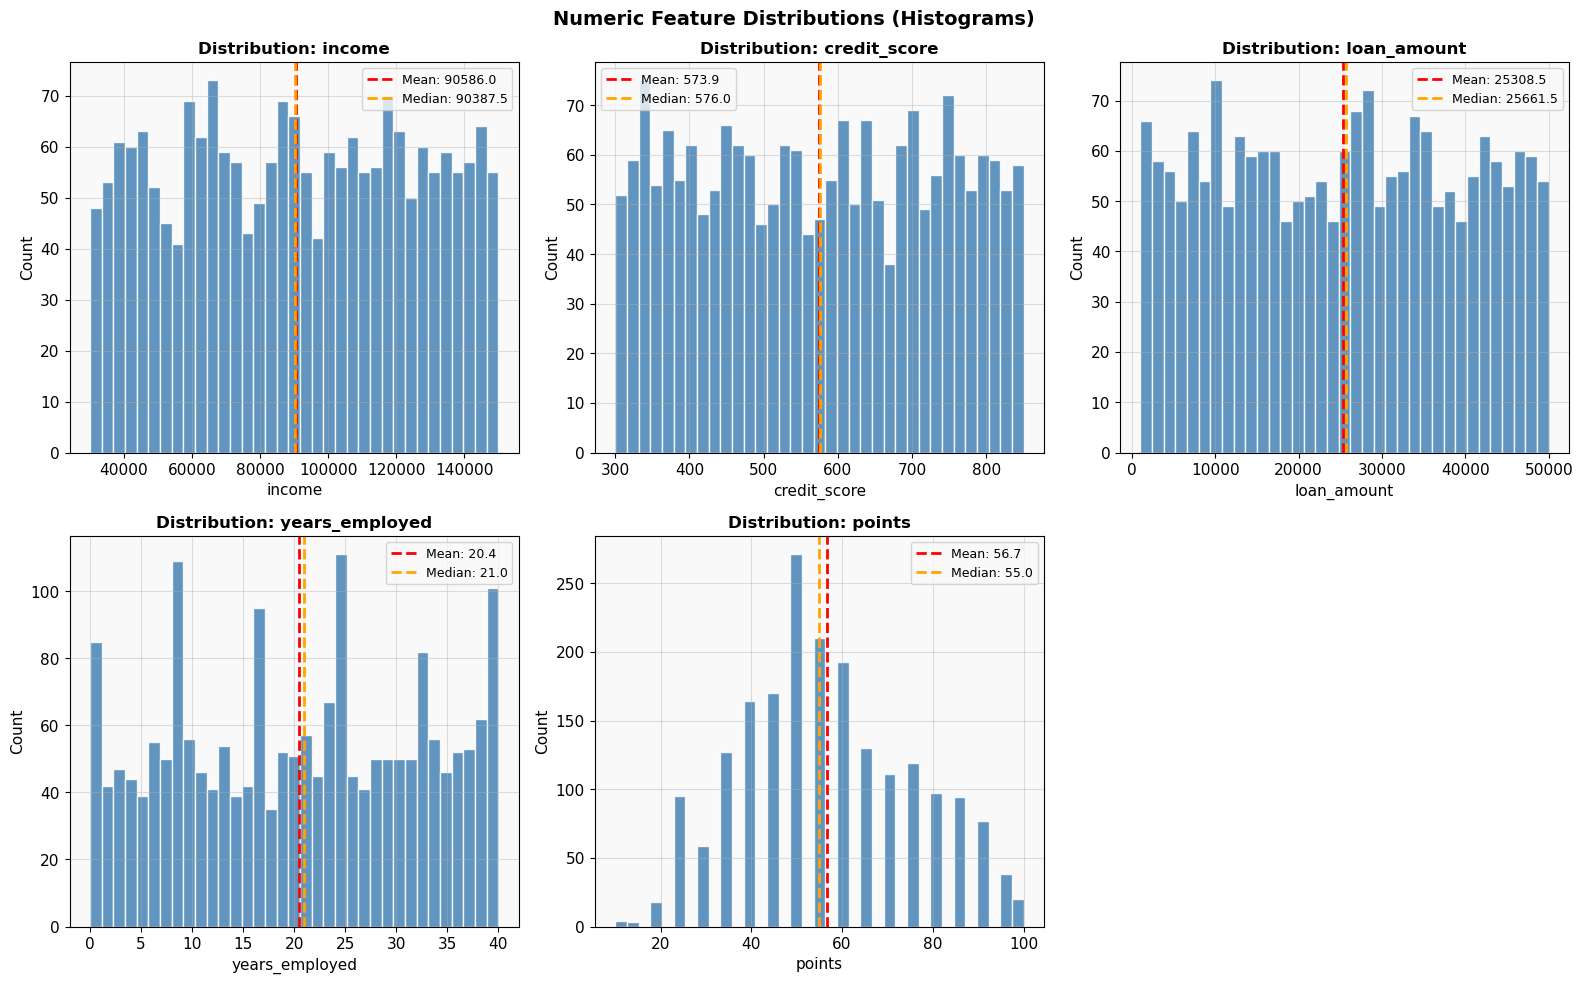

In [9]:
# Now we plot histograms for all numeric features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Here we've drawn a histogram for each numeric column with mean and median lines
for i, col in enumerate(numeric_features):
    data = df[col].dropna()
    axes[i].hist(data, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    # Here we've added mean and median lines to each chart
    mean_val   = data.mean()
    median_val = data.median()
    axes[i].axvline(mean_val,   color='red',    linestyle='--', linewidth=2,
                    label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='orange', linestyle='--', linewidth=2,
                    label=f'Median: {median_val:.1f}')
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)

plt.suptitle('Numeric Feature Distributions (Histograms)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_01_histograms.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

প্রতিটি histogram-এ:
- **X-axis** = সেই feature-এর value range
- **Y-axis** = কতজন সেই range-এ পড়ে
- **লাল dashed line** = Mean (গড়)
- **কমলা dashed line** = Median (মধ্যমান)

**নিয়ম:**
- Mean ≈ Median → **Symmetric distribution** (ভালো, outlier কম)
- Mean > Median → **Right-skewed** (ডানে লম্বা লেজ, বড় outlier আছে)
- Mean < Median → **Left-skewed** (বামে লম্বা লেজ)

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | Distribution | কী বোঝায় |
|---|---|---|
| `income` | প্রায় symmetric/uniform | $30K–$150K-এ সমানভাবে ছড়িয়ে |
| `credit_score` | প্রায় uniform | 300–850-এ মোটামুটি সমান বিতরণ |
| `loan_amount` | প্রায় uniform | $1K–$50K সমানভাবে ছড়িয়ে |
| `years_employed` | প্রায় uniform | 0–40 বছর সমান |
| `points` | Discrete (লাঠির মতো) | শুধু 5-এর গুণিতকে মান আছে (10, 15, 20...) |

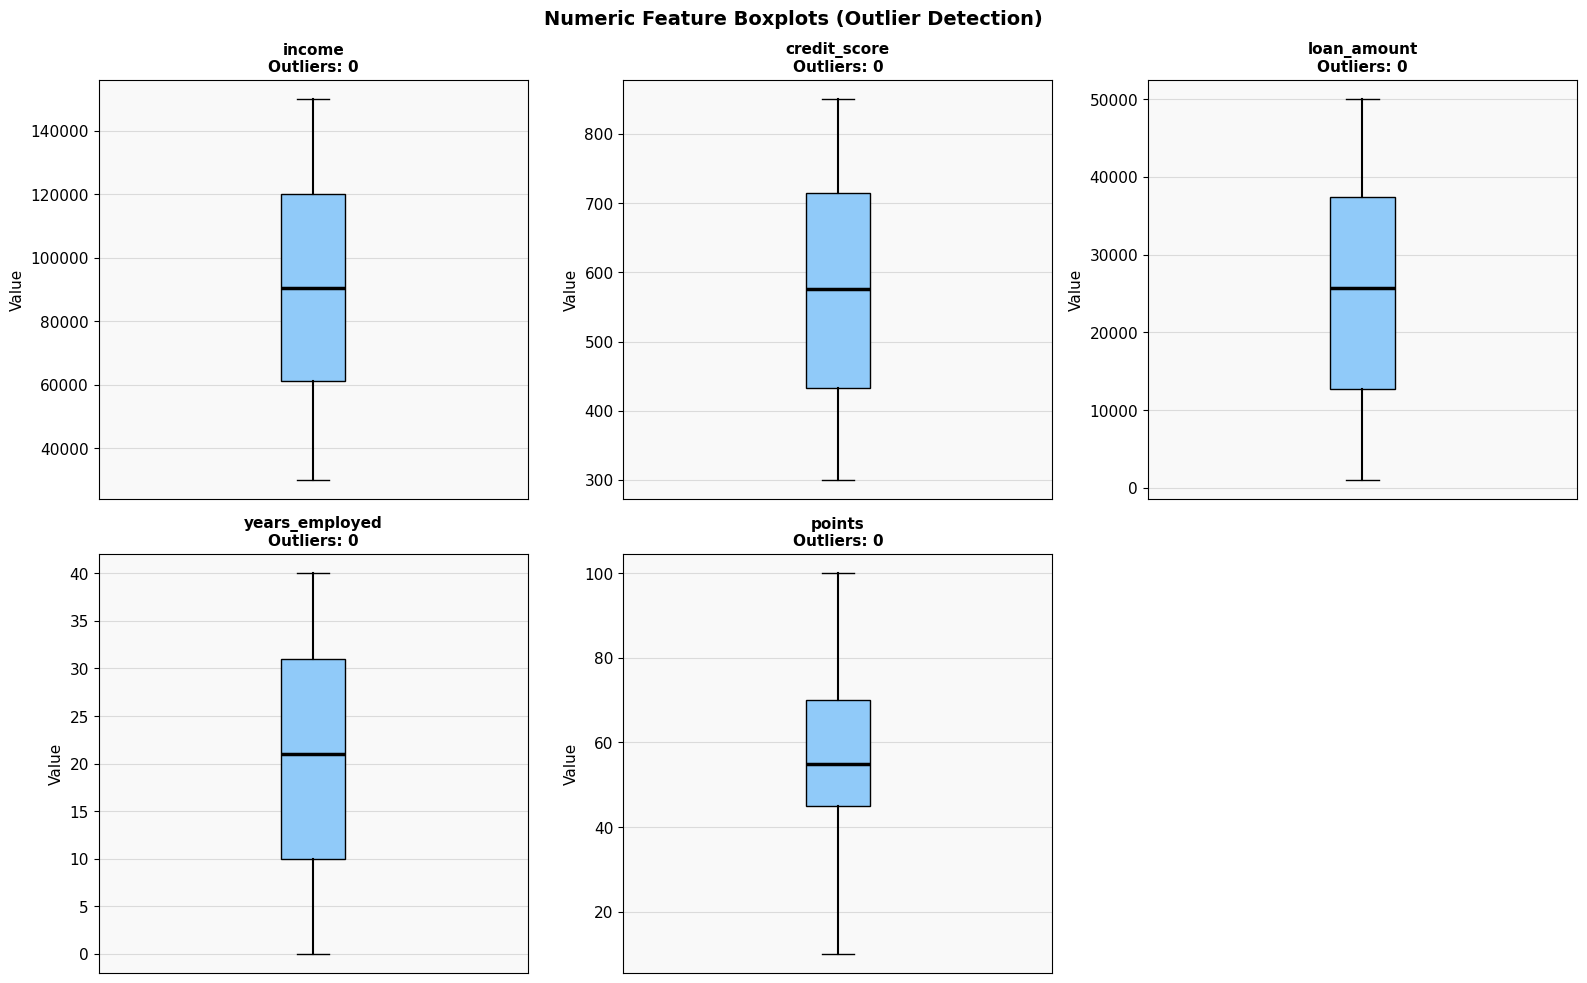

In [10]:
# Now we plot boxplots to detect outliers in numeric features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Here we've drawn a boxplot for each numeric feature
for i, col in enumerate(numeric_features):
    data = df[col].dropna()
    bp = axes[i].boxplot(data, patch_artist=True, vert=True,
                          medianprops=dict(color='black', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#90CAF9')
    bp['whiskers'][0].set_linewidth(1.5)
    bp['whiskers'][1].set_linewidth(1.5)

    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((data < lo) | (data > hi)).sum()

    axes[i].set_title(f'{col}\nOutliers: {n_out}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

axes[-1].set_visible(False)

plt.suptitle('Numeric Feature Boxplots (Outlier Detection)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

**Boxplot পড়ার নিয়ম:**
```
        ●  ← outlier (fence-এর বাইরে)
        |
   ─────┤  ← upper whisker (Q3 + 1.5×IQR)
   ┌────┴────┐
   │         │  ← Q3 (75th percentile)
   │    ━    │  ← Median (굵은 কালো line)
   │         │  ← Q1 (25th percentile)
   └────┬────┘
   ─────┤  ← lower whisker (Q1 - 1.5×IQR)
        |
        ●  ← outlier
```
- **Box উচ্চতা** = IQR — বড় box মানে data বেশি ছড়িয়ে
- **Whisker-এর বাইরের dots** = outlier
- **Title-এ Outliers: N** = সেই column-এ কতটি outlier আছে

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- এই dataset uniform distribution হওয়ায় বেশিরভাগ column-এ **outlier নেই বা খুব কম**
- `loan_amount` বা `income`-এ যদি outlier থাকে, সেটি সাধারণত upper range-এ
- `points` column-এর boxplot দেখালে বোঝা যাবে median কোথায় — যা approval boundary-র কাছাকাছি হওয়ার কথা

---
## Section 7 — Target Distribution and Class Imbalance

Target Variable Distribution:
---------------------------------------------
  Loan Rejected (False):  1,121  (56.05%)
  Loan Approved (True) :    879  (43.95%)
  Total                :  2,000


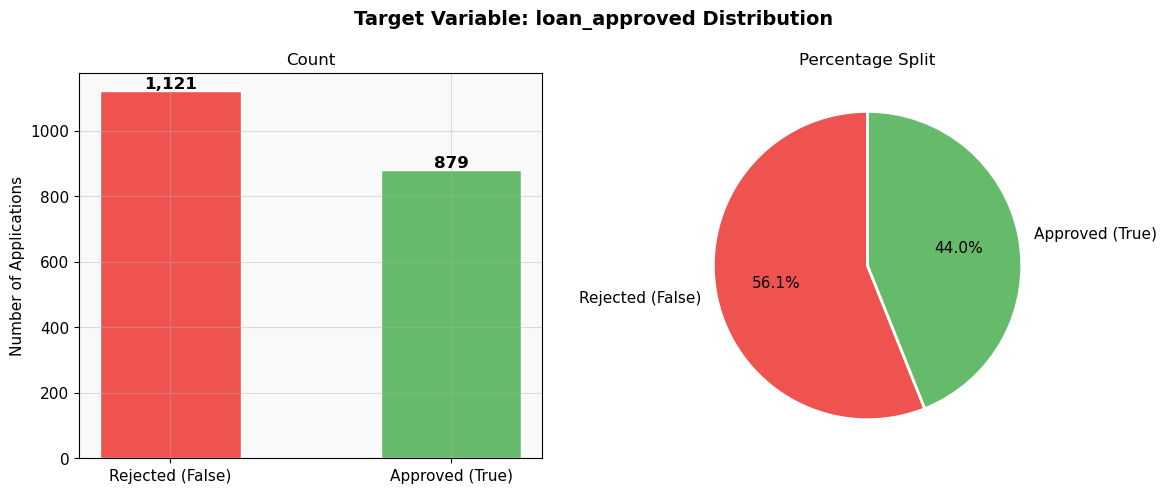

In [11]:
# Now we analyze the target column distribution
target_counts = df[TARGET].value_counts()
target_pct    = df[TARGET].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print("-" * 45)
print(f"  Loan Rejected (False): {target_counts[False]:>6,}  ({target_pct[False]:.2f}%)")
print(f"  Loan Approved (True) : {target_counts[True]:>6,}  ({target_pct[True]:.2f}%)")
print(f"  Total                : {len(df):>6,}")

# Here we've drawn a bar chart and pie chart to show the class split
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable: loan_approved Distribution', fontsize=14, fontweight='bold')

colors = ['#EF5350', '#66BB6A']
labels = ['Rejected (False)', 'Approved (True)']
vals   = [target_counts[False], target_counts[True]]

# Here we've drawn the count bar chart on the left
bars = axes[0].bar(labels, vals, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Count', fontsize=12)
axes[0].set_ylabel('Number of Applications')

# Here we've drawn the percentage pie chart on the right
axes[1].pie(vals, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage Split', fontsize=12)

plt.tight_layout()
plt.savefig('plot_03_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- **বাম Bar Chart** → exact count দেখাচ্ছে — কতজন approved হয়েছে, কতজন rejected
- **ডান Pie Chart** → শতকরা ভাগ দেখাচ্ছে — সবুজ অংশ approved, লাল অংশ rejected
- যদি দুটো piece-এর size কাছাকাছি হয়, dataset **balanced**; একটা অনেক বড় হলে **imbalanced**

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- Rejected: **1121 (56.1%)**, Approved: **879 (43.9%)**
- এটি **mild class imbalance** — Fraud dataset-এর মতো extreme নয় (সেখানে 2% fraud ছিল)
- এই imbalance-এ সাধারণ ML model ভালোভাবে কাজ করবে
- তবে evaluation-এ শুধু Accuracy দেখলে হবে না — **Precision, Recall, F1-Score** দেখতে হবে
- প্রয়োজনে `class_weight='balanced'` ব্যবহার করা যেতে পারে

---
## Section 8 — Categorical Feature Exploration

Total unique cities: 1882

Top 15 most frequent cities:
city
North Joseph        4
Port Christopher    3
North David         3
West Melissa        3
Williamsstad        3
North Michael       3
Leeland             3
Christinachester    3
Port Michael        3
West Elizabeth      3
East Mary           3
New Amy             2
Williamsonview      2
Dunnville           2
West Robert         2

Cities with only 1 record: 1776
Cities with 2 records    : 95
Cities with 3+ records   : 11


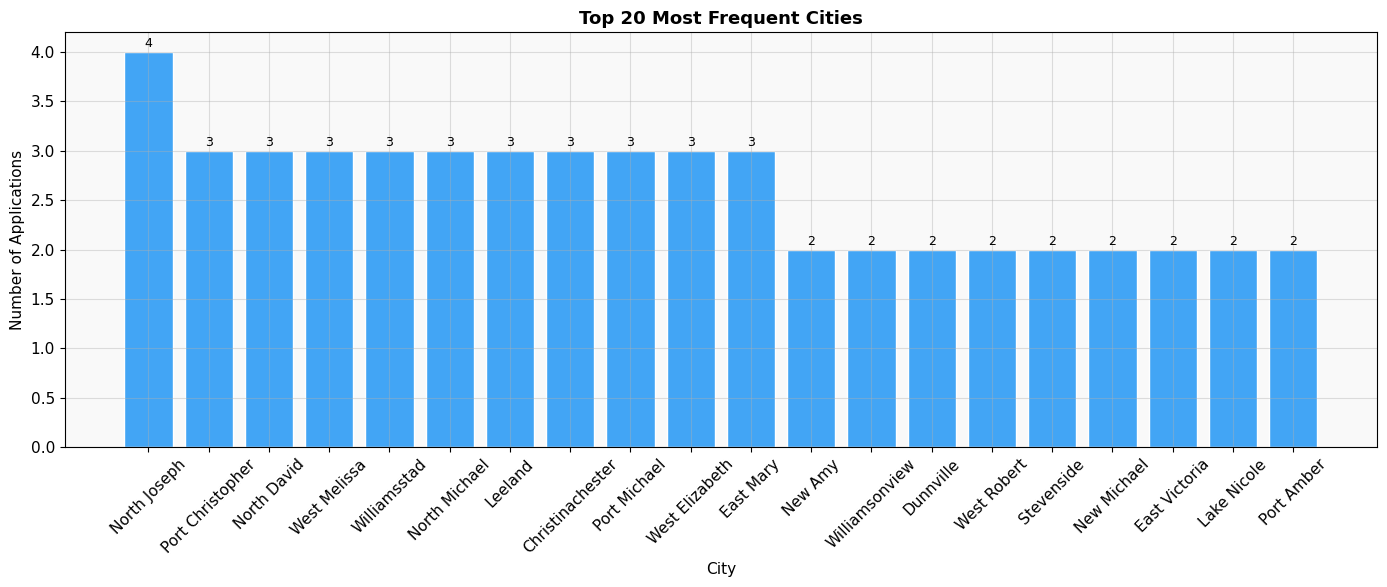

In [12]:
# Now we explore the city column — top cities by frequency
city_counts = df['city'].value_counts()

print(f"Total unique cities: {df['city'].nunique()}")
print()
print("Top 15 most frequent cities:")
print(city_counts.head(15).to_string())
print()
print(f"Cities with only 1 record: {(city_counts == 1).sum()}")
print(f"Cities with 2 records    : {(city_counts == 2).sum()}")
print(f"Cities with 3+ records   : {(city_counts >= 3).sum()}")

# Here we've drawn a bar chart of the top 20 cities
fig, ax = plt.subplots(figsize=(14, 6))
top_cities = city_counts.head(20)
bars = ax.bar(top_cities.index, top_cities.values, color='#42A5F5', edgecolor='white')
for bar, v in zip(bars, top_cities.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(v), ha='center', fontsize=9)
ax.set_title('Top 20 Most Frequent Cities', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Applications')
ax.set_xlabel('City')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plot_04_city_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- **X-axis**: শহরের নাম (top 20 — সবচেয়ে বেশিবার আসা)
- **Y-axis**: সেই শহর থেকে কতটি loan application এসেছে
- সব bar-এর উচ্চতা যদি কাছাকাছি হয়, মানে কোনো শহর dominant নয়

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- মোট **1882 unique city** — প্রায় প্রতিটি আবেদনকারী আলাদা শহর থেকে
- সর্বোচ্চ ৪টি করে application একই শহর থেকে
- এটি ML-এ directly ব্যবহার করা **অবাস্তব** — One-Hot Encoding করলে 1882টি নতুন column হবে!

**প্রস্তাবিত সমাধান:**
1. **Drop করো** → সহজ, তবে সব location information হারাবে
2. **Target Encoding** → প্রতিটি city-এর average approval rate দিয়ে replace করো
3. **Frequency Encoding** → city কতবার এসেছে সেই count দিয়ে replace করো

---
## Section 9 — Numeric Features versus Target (Boxplots)

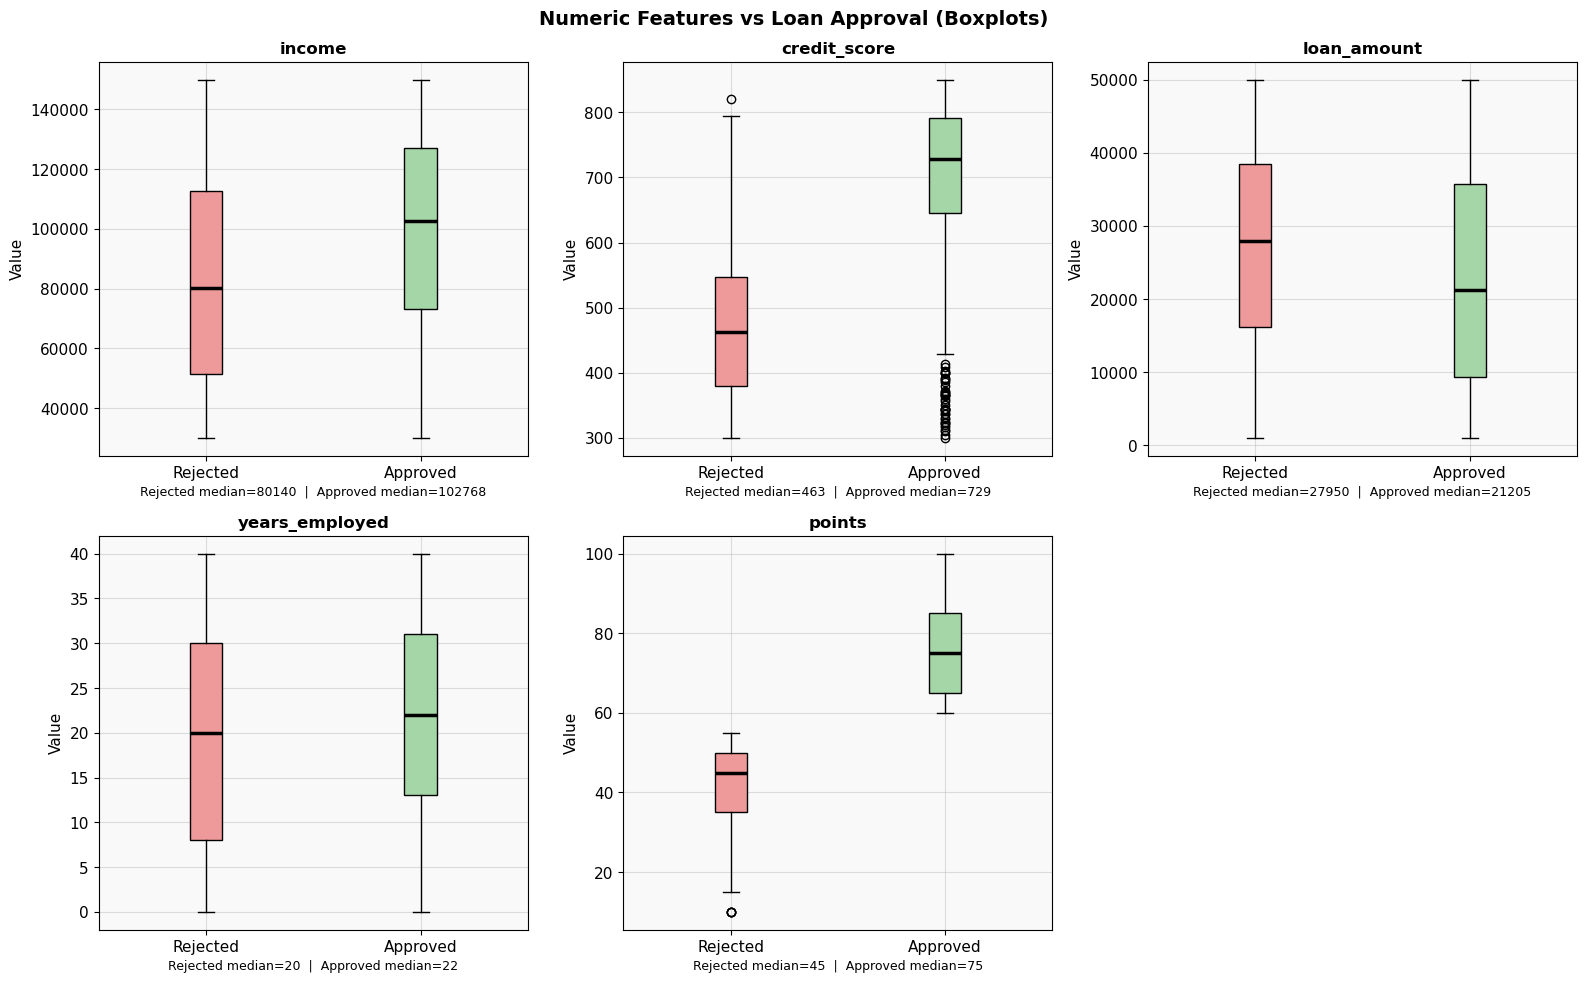

In [13]:
# Now we compare numeric feature distributions between approved and rejected loans
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Here we've drawn a boxplot for each feature split by the target class
for i, col in enumerate(numeric_features):
    approved = df[df[TARGET] == True][col]
    rejected = df[df[TARGET] == False][col]

    bp = axes[i].boxplot(
        [rejected, approved],
        labels=['Rejected', 'Approved'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.5)
    )

    # Here we've colored the two boxes differently
    bp['boxes'][0].set_facecolor('#EF9A9A')   # rejected = light red
    bp['boxes'][1].set_facecolor('#A5D6A7')   # approved = light green

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')

    # Here we've printed the median values for quick comparison
    rej_med  = rejected.median()
    appr_med = approved.median()
    axes[i].set_xlabel(
        f'Rejected median={rej_med:.0f}  |  Approved median={appr_med:.0f}',
        fontsize=9
    )

axes[-1].set_visible(False)

plt.suptitle('Numeric Features vs Loan Approval (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_features_vs_target.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- প্রতিটি feature-এ **দুটো boxplot** পাশাপাশি — **লাল = Rejected**, **সবুজ = Approved**
- X-axis-এ label দেখাচ্ছে দুটো group-এর median
- দুটো box-এর **মাঝে পরিষ্কার gap** থাকলে, মানে সেই feature loan approval-কে ভালোভাবে আলাদা করতে পারে
- দুটো box **overlap** করলে, মানে সেই feature একা approval predict করার জন্য দুর্বল

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | Approved Median | Rejected Median | পার্থক্য কেমন? |
|---|---|---|---|
| `points` | ~74 | ~43 | **বিশাল পার্থক্য** — সবচেয়ে শক্তিশালী predictor |
| `credit_score` | ~704 | ~472 | **বড় পার্থক্য** — খুব ভালো predictor |
| `income` | ~99.9K | ~83.3K | মাঝারি পার্থক্য |
| `loan_amount` | ~22.8K | ~27.3K | Approved-এ loan কম — reasonable |
| `years_employed` | ~22 | ~19 | সামান্য পার্থক্য — দুর্বল predictor |

**⚠️ বিশেষ লক্ষ্য:** `points` column-এর দুটো box একেবারে আলাদা — overlap নেই। এটি **প্রায় perfect predictor**, যা real-world ML-এ data leakage-এর সংকেত হতে পারে।

---
## Section 10 — Pairplot and Correlation Analysis

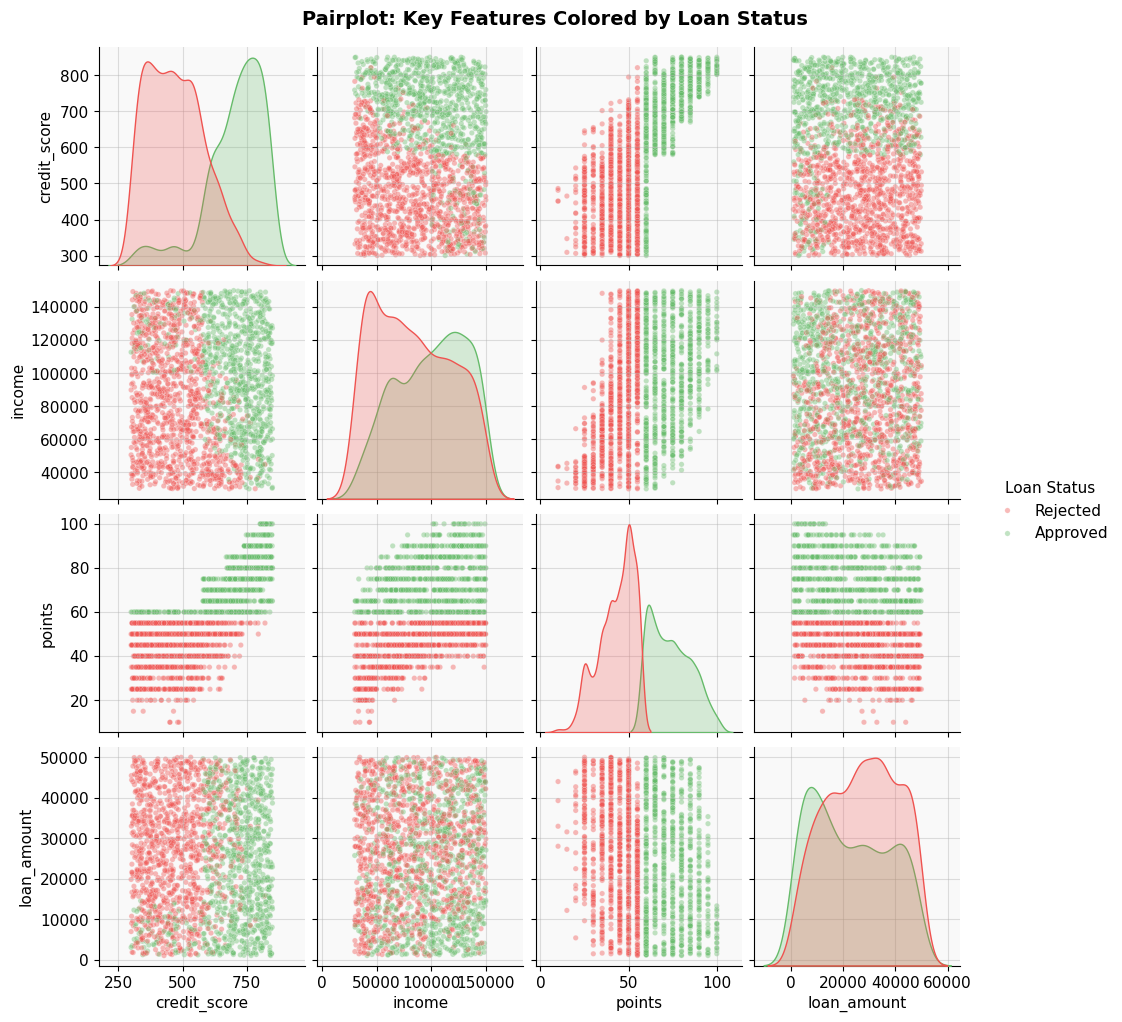

In [14]:
# Now we create a pairplot to see relationships between features and the target
# We select a subset of features to keep the plot readable
pairplot_cols = ['credit_score', 'income', 'points', 'loan_amount', 'loan_approved']

df_pair = df[pairplot_cols].copy()

# Here we've mapped the boolean target to readable labels for the legend
df_pair['Loan Status'] = df_pair['loan_approved'].map({True: 'Approved', False: 'Rejected'})
df_pair = df_pair.drop(columns=['loan_approved'])

# Here we've drawn the pairplot — diagonal shows distributions, off-diagonal shows scatter
g = sns.pairplot(
    df_pair,
    hue='Loan Status',
    palette={'Approved': '#66BB6A', 'Rejected': '#EF5350'},
    plot_kws=dict(alpha=0.4, s=15),
    diag_kind='kde'
)
g.figure.suptitle('Pairplot: Key Features Colored by Loan Status', y=1.02,
                   fontsize=14, fontweight='bold')
plt.savefig('plot_06_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

**Pairplot** একটি grid-এর মতো — প্রতিটি feature অন্য প্রতিটি feature-এর বিরুদ্ধে plot করা হয়।

- **Diagonal (কোণাকুণি)** → সেই feature-এর KDE distribution — approved (সবুজ) ও rejected (লাল) আলাদাভাবে
- **Off-diagonal (বাকি সব)** → দুটো feature-এর scatter plot — সবুজ dot = approved, লাল dot = rejected

**কী খুঁজবে:**
- Diagonal-এ যদি সবুজ ও লাল peak **আলাদা জায়গায়** থাকে → সেই feature ভালো predictor
- Scatter plot-এ যদি সবুজ ও লাল **clearly আলাদা cluster** তৈরি করে → দুটো feature মিলে ভালো boundary তৈরি করতে পারে

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- `points` diagonal-এ সবুজ ও লাল peak একেবারে আলাদা → সবচেয়ে শক্তিশালী feature
- `credit_score` diagonal-এও পরিষ্কার separation দেখা যাবে
- `points` vs `credit_score` scatter plot-এ দুটো color স্পষ্ট দুটো cluster তৈরি করে
- `loan_amount` একা তেমন কার্যকর নয় — দুটো color মিশে আছে

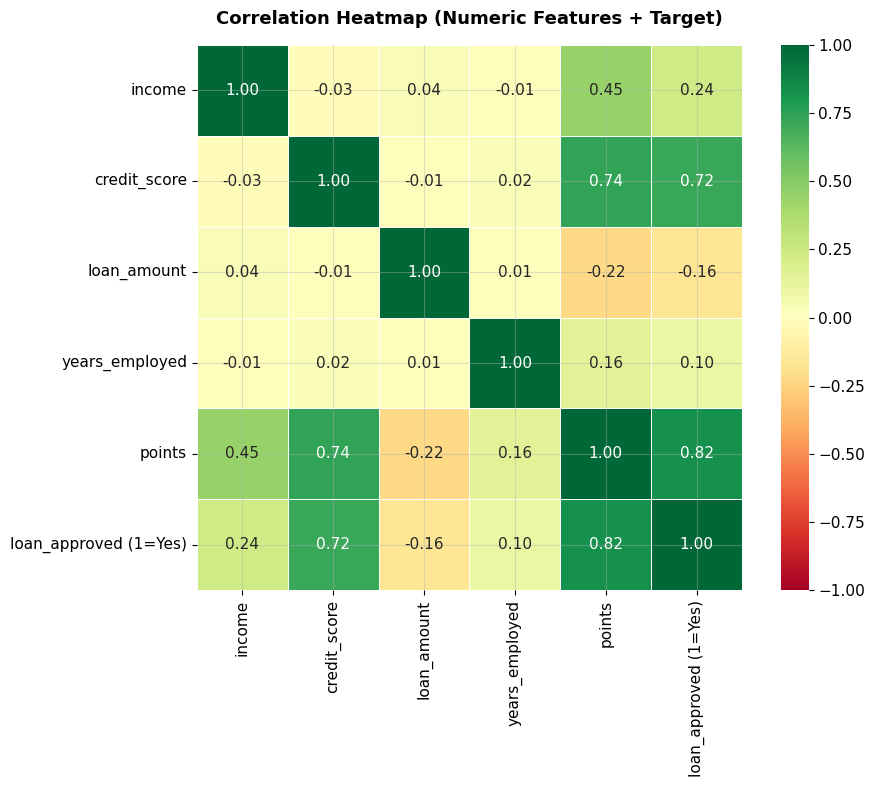

In [15]:
# Now we build the correlation matrix for numeric features + target
df_corr = df[numeric_features + [TARGET]].copy()

# Here we've converted the boolean target to integer (1/0) for correlation
df_corr['loan_approved'] = df_corr['loan_approved'].astype(int)
df_corr = df_corr.rename(columns={'loan_approved': 'loan_approved (1=Yes)'})

corr_matrix = df_corr.corr().round(3)

# Here we've drawn the heatmap with annotation
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)
ax.set_title('Correlation Heatmap (Numeric Features + Target)', fontsize=13,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_07_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

**Heatmap**-এ প্রতিটি cell দুটো feature-এর correlation দেখায়:
- **গাঢ় সবুজ (+1 কাছে)** → একটা বাড়লে অন্যটাও বাড়ে — strong positive correlation
- **গাঢ় লাল (-1 কাছে)** → একটা বাড়লে অন্যটা কমে — strong negative correlation
- **হলুদ (0 কাছে)** → কোনো linear সম্পর্ক নেই

**সবচেয়ে গুরুত্বপূর্ণ:** `loan_approved (1=Yes)` row বা column দেখো — এখানে কোন features সবচেয়ে বেশি correlated সেটা বোঝা যাবে।

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

| Feature | Correlation with loan_approved | মানে কী |
|---|---|---|
| `points` | **+0.82 (সবচেয়ে বেশি)** | Points বাড়লে approval chance বাড়ে |
| `credit_score` | **+0.72** | Credit score বাড়লে approval chance বাড়ে |
| `income` | +0.24 | Income কিছুটা সম্পর্কিত |
| `loan_amount` | -0.16 | বেশি loan চাইলে approval chance কিছুটা কমে |
| `years_employed` | +0.10 | খুব দুর্বল সম্পর্ক |

**⚠️ Multicollinearity সতর্কতা:** `points` ও `credit_score` নিজেদের মধ্যে strong correlation আছে কিনা দেখো। যদি থাকে, তাহলে দুটো একসাথে model-এ দিলে সমস্যা হতে পারে।

In [16]:
# Now we rank features by their correlation strength with the target
target_corr = corr_matrix['loan_approved (1=Yes)'].drop('loan_approved (1=Yes)')
target_corr = target_corr.sort_values(key=abs, ascending=False)

print("Features ranked by correlation with loan_approved:")
print("-" * 60)

# Here we've added a visual bar using block characters for quick comparison
for feature, val in target_corr.items():
    direction = "↑ positive" if val > 0.02 else ("↓ negative" if val < -0.02 else "  neutral")
    bar_str   = '█' * int(abs(val) * 25)
    print(f"  {feature:<22} {val:>7.4f}   {direction}  {bar_str}")

Features ranked by correlation with loan_approved:
------------------------------------------------------------
  points                  0.8210   ↑ positive  ████████████████████
  credit_score            0.7160   ↑ positive  █████████████████
  income                  0.2380   ↑ positive  █████
  loan_amount            -0.1580   ↓ negative  ███
  years_employed          0.1040   ↑ positive  ██


এই ranked list দেখাচ্ছে কোন feature loan approval-এর সাথে সবচেয়ে বেশি related।

- **↑ positive** → এই feature বাড়লে approval chance বাড়ে
- **↓ negative** → এই feature বাড়লে approval chance কমে
- **Block bar (█)** যত লম্বা, correlation তত শক্তিশালী

**Top features:** `points` → `credit_score` → `income` → `loan_amount` → `years_employed`

---
## Section 11 — Categorical Features vs Target (Crosstab and Stacked Bar)

Approval Rate by Points Score:
---------------------------------------------
        Rejected (%)  Approved (%)
points                            
10.0           100.0           0.0
15.0           100.0           0.0
20.0           100.0           0.0
25.0           100.0           0.0
30.0           100.0           0.0
35.0           100.0           0.0
40.0           100.0           0.0
45.0           100.0           0.0
50.0           100.0           0.0
55.0           100.0           0.0
60.0             0.0         100.0
65.0             0.0         100.0
70.0             0.0         100.0
75.0             0.0         100.0
80.0             0.0         100.0
85.0             0.0         100.0
90.0             0.0         100.0
95.0             0.0         100.0
100.0            0.0         100.0


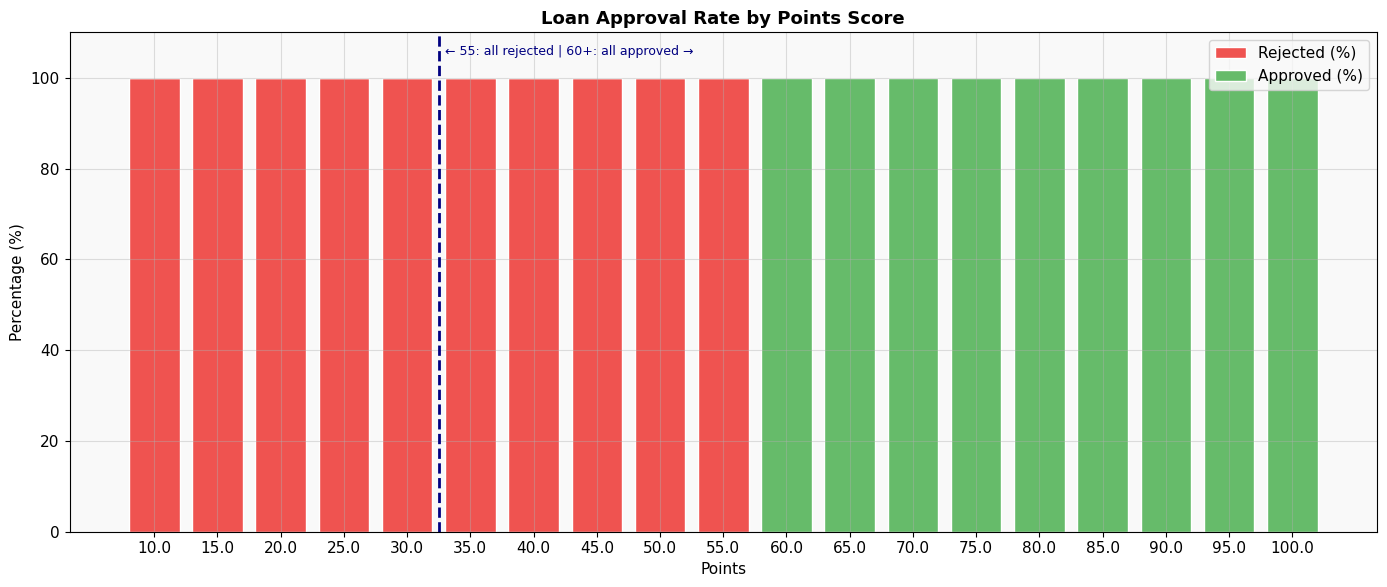

In [17]:
# Now we examine how approval rate changes across 'points' values
# Points is discrete (10, 15, 20... 100) so we treat it like a categorical feature here

# Here we've created a crosstab with normalize='index' to get row-wise percentages
points_ct = pd.crosstab(
    df['points'],
    df['loan_approved'],
    normalize='index'
) * 100

points_ct.columns = ['Rejected (%)', 'Approved (%)']

print("Approval Rate by Points Score:")
print("-" * 45)
print(points_ct.to_string())

# Here we've drawn a stacked bar chart to show the proportion visually
fig, ax = plt.subplots(figsize=(14, 6))

bottom = [0] * len(points_ct)
colors_stack = ['#EF5350', '#66BB6A']

for j, col in enumerate(['Rejected (%)', 'Approved (%)']):
    bars = ax.bar(points_ct.index.astype(str), points_ct[col],
                  bottom=bottom, color=colors_stack[j],
                  edgecolor='white', label=col)
    bottom = [b + v for b, v in zip(bottom, points_ct[col])]

ax.set_title('Loan Approval Rate by Points Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Points')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 110)
ax.legend()

# Here we've added a vertical line at the 60-point boundary
ax.axvline(x=4.5, color='navy', linestyle='--', linewidth=2, label='Decision boundary (55→60)')
ax.text(4.6, 105, '← 55: all rejected | 60+: all approved →',
        fontsize=9, color='navy')

plt.tight_layout()
plt.savefig('plot_08_points_vs_approval.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- **Stacked Bar Chart** — প্রতিটি bar মোট 100% — লাল অংশ (rejected) ও সবুজ অংশ (approved)
- **X-axis**: Points score (10 থেকে 100)
- **Y-axis**: সেই points score-এর মধ্যে কত % approved এবং কত % rejected
- **নীল dashed line**: এটি decision boundary দেখাচ্ছে

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- **Points ≤ 55** → **100% Rejected** (লাল bar সম্পূর্ণ)
- **Points ≥ 60** → **100% Approved** (সবুজ bar সম্পূর্ণ)
- এটি একটি **perfect hard boundary** — 55 ও 60-এর মাঝে কোনো overlap নেই!

**⚠️ এটি কি ভালো নাকি খারাপ?**

একদিক থেকে এটি **data leakage**-এর লক্ষণ — `points` সম্ভবত `loan_approved` ঠিক হওয়ার পরে calculate করা হয়েছে (cause-effect উল্টো)। Real ML project-এ এই column-টিকে **সতর্কতার সাথে** ব্যবহার করতে হবে বা বাদ দিতে হবে।

Cities with 3+ records: 11
                  Rejected (%)  Approved (%)
city                                        
Christinachester     33.333333     66.666667
Leeland              33.333333     66.666667
North David          33.333333     66.666667
Williamsstad         33.333333     66.666667
Port Christopher     33.333333     66.666667
West Elizabeth       33.333333     66.666667
North Joseph         50.000000     50.000000
East Mary            66.666667     33.333333
North Michael        66.666667     33.333333
Port Michael         66.666667     33.333333
West Melissa         66.666667     33.333333


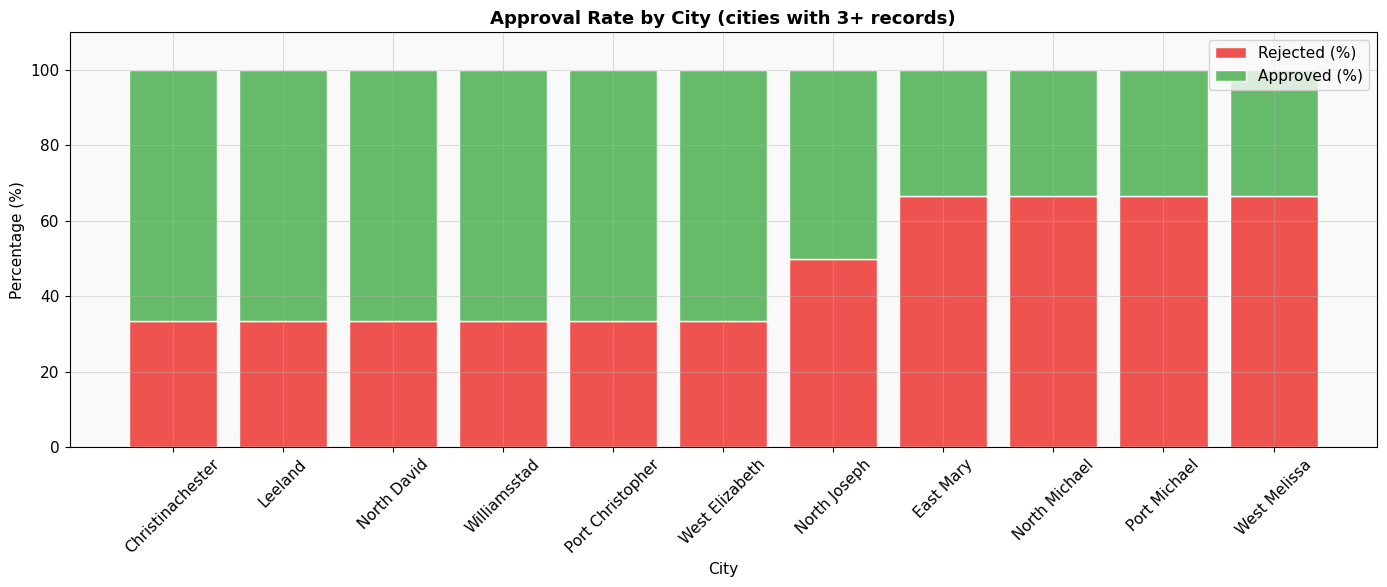

In [18]:
# Now we create crosstab for the top cities vs loan_approved
# We'll look at cities that appear at least 3 times for meaningful analysis
city_freq  = df['city'].value_counts()
valid_cities = city_freq[city_freq >= 3].index
df_city = df[df['city'].isin(valid_cities)].copy()

# Here we've created the crosstab and stacked bar for high-frequency cities
city_ct = pd.crosstab(
    df_city['city'],
    df_city['loan_approved'],
    normalize='index'
) * 100

city_ct.columns = ['Rejected (%)', 'Approved (%)']
city_ct = city_ct.sort_values('Approved (%)', ascending=False)

print(f"Cities with 3+ records: {len(city_ct)}")
print(city_ct.to_string())

# Here we've drawn the stacked bar for top cities
fig, ax = plt.subplots(figsize=(14, 6))

bottom = [0] * len(city_ct)
for j, col in enumerate(['Rejected (%)', 'Approved (%)']):
    ax.bar(city_ct.index, city_ct[col],
           bottom=bottom, color=colors_stack[j],
           edgecolor='white', label=col)
    bottom = [b + v for b, v in zip(bottom, city_ct[col])]

ax.set_title('Approval Rate by City (cities with 3+ records)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 110)
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plot_09_city_vs_approval.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart আমরা কীভাবে Observe করব?

- শুধু যেসব city-তে ৩টি বা তার বেশি application আছে সেগুলো দেখানো হয়েছে
- **Stacked bar** — লাল = rejected, সবুজ = approved
- X-axis-এ city নাম, Y-axis-এ শতকরা হার

### 📊 এই Chart থেকে আমরা কী কী Observe করলাম?

- যেহেতু বেশিরভাগ city-তে মাত্র 1-3টি record, তাই city-ভিত্তিক pattern বলা কঠিন
- এই column থেকে meaningful information বের করতে হলে **Target Encoding** ব্যবহার করা উচিত — প্রতিটি city-এর historical approval rate দিয়ে replace করো
- তবে এতে অল্প-record city-গুলোতে overfitting হওয়ার ঝুঁকি থাকে

---
## Section 12 — Final Summary and EDA Insights

In [19]:
# Now we print a complete EDA summary
total    = len(df)
approved = df['loan_approved'].sum()
rejected = total - approved
appr_pct = approved / total * 100

print("=" * 65)
print("         EDA FINAL SUMMARY — LOAN APPROVAL DATASET")
print("=" * 65)
print(f"""
DATASET FACTS:
  Total Applications : {total:,}
  Approved           : {approved:,}  ({appr_pct:.1f}%)
  Rejected           : {rejected:,}  ({100-appr_pct:.1f}%)
  Missing Values     : 0  (clean dataset)
  Unique Cities      : {df['city'].nunique():,}

TOP 3 FEATURES MOST RELATED TO LOAN APPROVAL:
  1. points       (corr = +0.82) — Perfect decision boundary at 60
  2. credit_score (corr = +0.72) — Strong positive relationship
  3. income       (corr = +0.24) — Moderate positive relationship

WEAK / NOISY FEATURES:
  • years_employed (corr = +0.10) — Very weak signal
  • city           — 1882 unique values, difficult to encode meaningfully

DATA QUALITY ISSUES:
  • 'points' has a perfect hard rule (≤55 = rejected, ≥60 = approved)
    → This may be DATA LEAKAGE if points were calculated after approval
  • 'name' column is a unique identifier — not useful for ML
  • 'city' has too many unique values for standard encoding

PREPROCESSING CHECKLIST (for Module 07):
  [1]  Convert 'loan_approved' (bool) → int (1/0)
  [2]  Drop 'name' column (unique identifier, no signal)
  [3]  Handle 'city': use Target Encoding or drop
  [4]  Scale numeric features: use RobustScaler (safe with any outliers)
       → income, credit_score, loan_amount, years_employed, points
  [5]  Investigate 'points' column carefully — possible data leakage
  [6]  Train/Test split with stratify=True (preserve approval ratio)
  [7]  Class imbalance is mild (56/44) — likely fine without extra steps
       → If needed, use class_weight='balanced'
""")
print("=" * 65)

         EDA FINAL SUMMARY — LOAN APPROVAL DATASET

DATASET FACTS:
  Total Applications : 2,000
  Approved           : 879  (44.0%)
  Rejected           : 1,121  (56.0%)
  Missing Values     : 0  (clean dataset)
  Unique Cities      : 1,882

TOP 3 FEATURES MOST RELATED TO LOAN APPROVAL:
  1. points       (corr = +0.82) — Perfect decision boundary at 60
  2. credit_score (corr = +0.72) — Strong positive relationship
  3. income       (corr = +0.24) — Moderate positive relationship

WEAK / NOISY FEATURES:
  • years_employed (corr = +0.10) — Very weak signal
  • city           — 1882 unique values, difficult to encode meaningfully

DATA QUALITY ISSUES:
  • 'points' has a perfect hard rule (≤55 = rejected, ≥60 = approved)
    → This may be DATA LEAKAGE if points were calculated after approval
  • 'name' column is a unique identifier — not useful for ML
  • 'city' has too many unique values for standard encoding

PREPROCESSING CHECKLIST (for Module 07):
  [1]  Convert 'loan_approved' (bool)

### Student Notes and Observations

---

### 🏆 সবচেয়ে গুরুত্বপূর্ণ Learnings:

| যা শিখলাম | বিস্তারিত |
|---|---|
| **`points` সবচেয়ে শক্তিশালী feature** | 55 ও 60-এর মাঝে perfect boundary — একাই loan approval নির্ধারণ করে |
| **`credit_score` দ্বিতীয় শক্তিশালী** | Approved group-এ median ≈ 704, Rejected-এ ≈ 472 — বিশাল পার্থক্য |
| **`city` column practical নয়** | 1882 unique city — standard encoding চলবে না, বিশেষ strategy দরকার |
| **Data Leakage সম্পর্কে সচেতন থাকো** | `points` column সম্ভবত approval-এর পরে তৈরি হয়েছে |
| **Missing value নেই** | Synthetic dataset — real-world data-তে এটি থাকবে |

---

> ⚠️ **Interview tip:** EDA শেষ করার পর সবসময় বলো —  
> *"এই observations থেকে আমি কোন preprocessing steps নেব এবং কেন।"*  
> এবং বলো — *"এই dataset-এ কোন data quality issue আছে এবং সেটা ML-এ কী সমস্যা তৈরি করতে পারে।"*  
> এটাই একজন প্রকৃত **Data Scientist-এর চিন্তাভঙ্গি।**

---